# Air Quality Raw Data Exploration & Ingestion
### Analysis of 3-Year Hourly EPD Air Quality Records (2019–2021)

This notebook inspects and profiles the raw air quality observations recorded across 16 environmental monitoring stations in Hong Kong.

In [2]:
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dynamic root resolution
current = Path.cwd().resolve()
project_root = current
for candidate in [current, *current.parents]:
    if (candidate / "data" / "raw").exists():
        project_root = candidate
        break

DATA_DIR = project_root / "data" / "raw" / "air_quality"
csv_path = DATA_DIR / "epd_air_quality_2019_2021_hourly.csv"

print(f"Data file: {csv_path}")
print(f"File exists: {csv_path.exists()}")

Data file: /home/mocha/Desktop/ctdi-model-project/data/raw/air_quality/epd_air_quality_2019_2021_hourly.csv
File exists: True


## 1. Load Raw Dataset
Loading the complete 3-year hourly dataset with timestamp parsing.

In [3]:
df = pd.read_csv(csv_path, parse_dates=["timestamp"],usecols=lambda x: x not in ['co', 'nox'])
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage:  {df.memory_usage().sum() / (1024**2):.2f} MB")
display(df.head())

Dataset shape: 420,864 rows × 8 columns
Memory usage:  29.40 MB


,station_id,station_name,timestamp,pm25,pm10,no2,o3,so2
0,71,CAUSEWAY BAY,2019-01-01 00:00:00,31.0,42.0,67.0,2.0,9.0
1,71,CAUSEWAY BAY,2019-01-01 01:00:00,31.0,41.0,60.0,3.0,5.0
2,71,CAUSEWAY BAY,2019-01-01 02:00:00,27.0,36.0,40.0,7.0,3.0
3,71,CAUSEWAY BAY,2019-01-01 03:00:00,NaN,NaN,37.0,9.0,3.0
4,71,CAUSEWAY BAY,2019-01-01 04:00:00,NaN,NaN,29.0,11.0,3.0


## 2. Station & Temporal Coverage
Checking that all 16 stations possess the expected 26,304 hourly timestamps (1,096 days × 24 hours).

In [4]:
stations = df.groupby(["station_id", "station_name"]).agg(
    records=("timestamp", "count"),
    start_date=("timestamp", "min"),
    end_date=("timestamp", "max")
).reset_index()

stations["expected"] = 26304
stations["is_complete"] = stations["records"] == stations["expected"]
display(stations)

,station_id,station_name,records,start_date,end_date,expected,is_complete
0,66,SHAM SHUI PO,26304,2019-01-01,2021-12-31 23:00:00,26304,True
1,69,TAI PO,26304,2019-01-01,2021-12-31 23:00:00,26304,True
2,70,YUEN LONG,26304,2019-01-01,2021-12-31 23:00:00,26304,True
3,71,CAUSEWAY BAY,26304,2019-01-01,2021-12-31 23:00:00,26304,True
4,72,KWAI CHUNG,26304,2019-01-01,2021-12-31 23:00:00,26304,True
5,73,EASTERN,26304,2019-01-01,2021-12-31 23:00:00,26304,True
6,74,KWUN TONG,26304,2019-01-01,2021-12-31 23:00:00,26304,True
7,75,SHATIN,26304,2019-01-01,2021-12-31 23:00:00,26304,True
8,76,TAP MUN,26304,2019-01-01,2021-12-31 23:00:00,26304,True
9,77,TSUEN WAN,26304,2019-01-01,2021-12-31 23:00:00,26304,True


## 3. Missingness Profiling
Evaluating missing value percentages across the criteria pollutants: PM2.5, PM10, NO2, O3, SO2, NOx, and CO.

,Missing Count,Missing Rate (%)
pm25,10657,2.53
pm10,11395,2.71
no2,11651,2.77
o3,11117,2.64
so2,11056,2.63


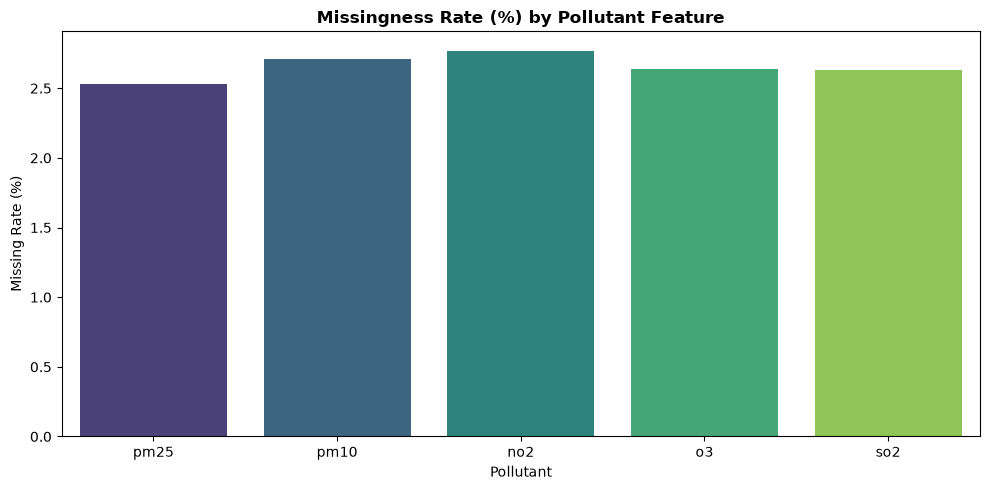

In [ ]:
pollutants = ["pm25", "pm10", "no2", "o3", "so2"]
missing_summary = pd.DataFrame({
    "Missing Count": df[pollutants].isnull().sum(),
    "Missing Rate (%)": (df[pollutants].isnull().mean() * 100).round(2)
})
display(missing_summary)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_summary.index, y="Missing Rate (%)", data=missing_summary, palette="viridis")
plt.title("Missingness Rate (%) by Pollutant Feature", fontweight="bold")
plt.ylabel("Missing Rate (%)")
plt.xlabel("Pollutant")
plt.tight_layout()
plt.show()

## 4. Statistical Distributions
Descriptive statistics and summary distributions for pollutant concentrations.

,pm25,pm10,no2,o3,so2
count,410207.00,409469.00,409213.00,409747.00,409808.00
mean,17.46,29.65,42.85,50.77,4.85
std,12.03,19.31,31.10,38.60,2.95
min,0.00,0.00,0.00,0.00,0.00
25%,9.00,16.00,20.00,21.00,3.00
50%,15.00,26.00,36.00,42.00,4.00
75%,23.00,39.00,58.00,74.00,6.00
max,167.00,241.00,366.00,422.00,81.00


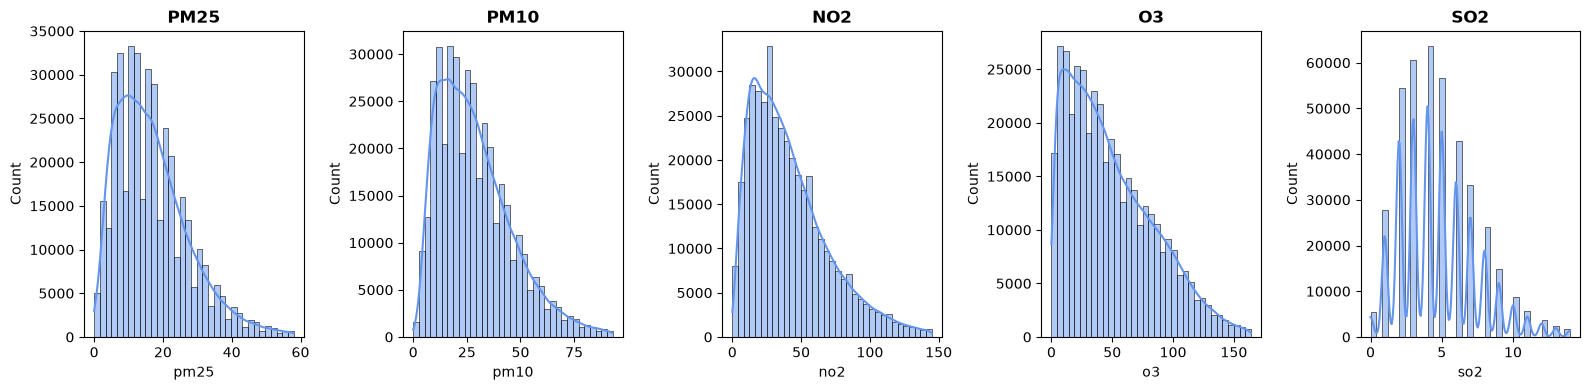

In [12]:
display(df[pollutants].describe().round(2))

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for idx, p in enumerate(["pm25", "pm10", "no2", "o3","so2"]):
    val = df[p].dropna()
    p99 = np.percentile(val, 99)
    sns.histplot(val[val <= p99], bins=35, kde=True, ax=axes[idx], color="cornflowerblue")
    axes[idx].set_title(p.upper(), fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Summary & Verification
The raw air quality dataset is structured, validated, and ready for multi-modal alignment or model training.